## **Librerias y Dependencias**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

## **Parte I - 5p**

Se utiliza un cuerpo de plexiglás de forma semicircular, que se coloca en el centro del disco óptico graduado, de modo que el rayo incidente penetra siempre normalmente en el cuerpo de plexiglás, sufriendo solo refracción al atravesar la superficie plana.

Utilizando la fuente de luz con emisión de un único rayo y asegurándose de que la incidencia sea siempre normal a la superficie curva (apuntando al centro del disco), colocar el rayo incidente con $\theta_1 = 0^\circ$.  

A partir de esta posición, girar el disco de 5 en 5 grados y realizar una tabla con los ángulos de incidencia y de refracción con sus errores absolutos.

Obtener experimentalmente el ángulo crítico, comprobando a partir de qué ángulo $\theta_1$ desaparece el rayo refractado.

Teniendo en cuenta la Ley de Snell, representar gráficamente $\sin\theta_1$ frente a $\sin\theta_2$.  

A partir de dicha gráfica, obtener el valor del índice de refracción del plexiglás $n_2$ con su error (recordamos que el valor del índice de refracción del aire, $n_1$, se asume como 1).

A partir de este valor de $n$, obtener el ángulo crítico con su error. Comparar este valor para el ángulo crítico con el obtenido experimentalmente y comparar la diferencia entre ambos valores con el error estimado para la medida.


### _Datos_


In [3]:
theta1_vals = [90 - x for x in range(50,95,5)]
measured_vals = [16,31,41,51,59,68,74,81,90]

theta2_vals = [90 - y for y in measured_vals]

for i in range(len(theta1_vals)):
    print(f"Angulo Incidencia: {theta1_vals[i]} ± 0.5º --> Angulo Refracción: {theta2_vals[i]} ± 0.5º")

Angulo Incidencia: 40 ± 0.5º --> Angulo Refracción: 74 ± 0.5º
Angulo Incidencia: 35 ± 0.5º --> Angulo Refracción: 59 ± 0.5º
Angulo Incidencia: 30 ± 0.5º --> Angulo Refracción: 49 ± 0.5º
Angulo Incidencia: 25 ± 0.5º --> Angulo Refracción: 39 ± 0.5º
Angulo Incidencia: 20 ± 0.5º --> Angulo Refracción: 31 ± 0.5º
Angulo Incidencia: 15 ± 0.5º --> Angulo Refracción: 22 ± 0.5º
Angulo Incidencia: 10 ± 0.5º --> Angulo Refracción: 16 ± 0.5º
Angulo Incidencia: 5 ± 0.5º --> Angulo Refracción: 9 ± 0.5º
Angulo Incidencia: 0 ± 0.5º --> Angulo Refracción: 0 ± 0.5º


## *Graficar* $\sin\theta_1$ *frente a* $\sin\theta_2$ 

In [4]:
sen_theta1_vals = np.array([np.sin(np.deg2rad(i)) for i in theta1_vals]).reshape((-1,1)) # np.sin requiere angulos en radianes
sen_theta2_vals = [np.sin(np.deg2rad(i)) for i in theta2_vals]

for i in range(len(theta1_vals)):
    print(f"sen(theta1): {sen_theta1_vals[i]} --> sen(theta2): {sen_theta2_vals[i]}")


sen(theta1): [0.64278761] --> sen(theta2): 0.9612616959383189
sen(theta1): [0.57357644] --> sen(theta2): 0.8571673007021123
sen(theta1): [0.5] --> sen(theta2): 0.754709580222772
sen(theta1): [0.42261826] --> sen(theta2): 0.6293203910498374
sen(theta1): [0.34202014] --> sen(theta2): 0.5150380749100542
sen(theta1): [0.25881905] --> sen(theta2): 0.374606593415912
sen(theta1): [0.17364818] --> sen(theta2): 0.27563735581699916
sen(theta1): [0.08715574] --> sen(theta2): 0.15643446504023087
sen(theta1): [0.] --> sen(theta2): 0.0


m: 1.4770045573298152. c: 0.010248671323028091. R^2: 0.9994889233977458


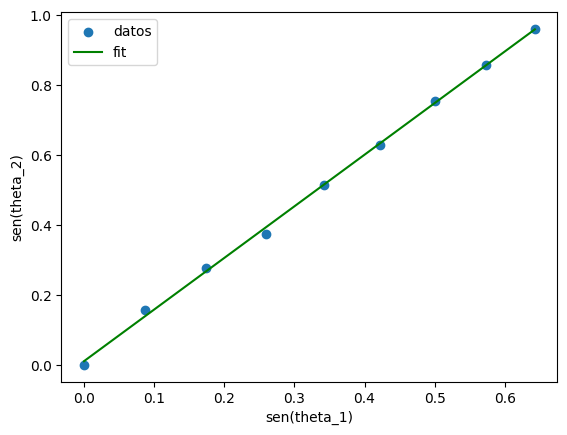

In [5]:
x = sen_theta1_vals.flatten()
y = np.array(sen_theta2_vals)

m,c,r_sq,p_val,error_n = linregress(x,y)

print(f"m: {m}. c: {c}. R^2: {r_sq}")

plt.scatter(x,y, label="datos")
plt.plot(x, m*x + c, label="fit", color="g")
plt.xlabel("sen(theta_1)")
plt.ylabel("sen(theta_2)")
plt.legend()
plt.show()

## _Encontrar_ $n_1$.

Se asume que $n_2 = 1$  

$n_1sen(\theta _1) = sen(\theta _2)$

$n_1 = \frac{sen(\theta _2)}{sen(\theta _1)}$

$n_1 = pendiente$

In [6]:
n_1 = m
print(f"n del plexigas: {n_1:2f} ± {error_n:3f}")

n del plexigas: 1.477005 ± 0.017855


## _Encontrar angulo critico_

$\theta _2 = 90º$

$n_1sen(\theta _c) = sen(90)$

$\theta _c = arcsen(\frac{1}{n_1})$

In [7]:
theta_c_measured = 42
error_theta_c_measured = 0.5

theta_c = np.rad2deg(np.arcsin(1/n_1))
error_theta_c = np.rad2deg(1 / np.sqrt(n_1**2 - 1) * error_n)
print(f"Angulo Critico Medido: {theta_c_measured} ± {error_theta_c_measured}º")
print(f"Angulo Critico Calculado: {theta_c:.2f} ± {error_theta_c:2f}º")

err_abs = np.abs(theta_c_measured - theta_c)
err_rel = (err_abs / theta_c)*100

print(f"Error Absoluto: {err_abs:3f}º")
print(f"Error Relativo: {err_rel/theta_c:.2f}%")

Angulo Critico Medido: 42 ± 0.5º
Angulo Critico Calculado: 42.61 ± 0.941142º
Error Absoluto: 0.613235º
Error Relativo: 0.03%


# **Parte 2 - 2p**

Utilizando el papel milimetrado y la fuente de luz en modo múltiple, realizar el trazado de rayos
para dos de las lentes convergentes y una lente divergente, y a partir de ellos calcular la
distancia focal de estas lentes. Realizar la misma operación con el espejo convexo y hallar
su distancia focal, así como su radio de curvatura. Estimar en todos los casos el error
cometido en estos resultados.

La unica fuente de error sale del papel milimetrado ya que solo podemos medir de 1mm a 1mm. Entonces si tenemos un punto que esta entre 2 lineas, tenemos que redondear. Por ejemplo si esta entre 14.5 y 14.6, si esta mas cerca de 14.6 cogeremos 14.6 en vez de 14.5. Por ello nuestro error es de $\pm 0.05cm$ 

Para calcular el radio de curvatura del espejo se usa la formula $f = \frac{R}{2} \rightarrow R = 2f$

Para calcular el radio de curvatura de una lente se usa la fomula del fabricante $\frac{1}{f} = (n-1)(\frac{1}{R_1} - \frac{1}{R_2})$.  
El nuestro caso, $-R_1 = R_2$ asi que $\frac{1}{f} = (n-1)(\frac{2}{R}) \rightarrow R = 2f(n-1)$

In [ ]:
datos_p2 = {
    "Lente Convergerte 1": 19.9,
    "Lente Convergente 2": 15.1,
    "Lente Divergente 1": -11.1,
    "Espejo Convexo": -1.4
}

R_lente = lambda f,n: 2*f*(n-1) #Funcion para calcular el radio de curvatura de una lente
R_espejo = lambda f: 2*f # Funcion para calcular el radio de curvatura de un espejo
error_f = 0.05
error_R_espejo = lambda err_f: 2* err_f #Funcion para calcular error absoluto del espejo
error_R_lente = lambda err_f, err_n,n,f: np.sqrt((2*(n-1))**2 * err_f**2 + (2*f)**2 * err_n**2) #Funcion para calcular error absoluto de la lente

In [9]:
for tipo_lente,f in datos_p2.items():

    if "Espejo" in tipo_lente:
        R = np.fabs(R_espejo(f))
        error_R = error_R_espejo(error_f)
    else:
        R = np.fabs(R_lente(f,n_1))
        error_R = error_R_lente(error_f,error_n,n_1,f)
    
    error_relativo = (error_R/R)*100

    print(f"{tipo_lente} --> f={f} ± {error_f}cm --> R={R} ± {error_R}cm. Error Relativo: {error_relativo:.2f}%")

Lente Convergerte 1 --> f=19.9 ± 0.05cm --> R=18.98478138172664 ± 0.712224009302115cm. Error Relativo: 3.75%
Lente Convergente 2 --> f=15.1 ± 0.05cm --> R=14.405537631360417 ± 0.541323600756292cm. Error Relativo: 3.76%
Lente Divergente 1 --> f=-11.1 ± 0.05cm --> R=10.589501172721896 ± 0.39923853071779375cm. Error Relativo: 3.77%
Espejo Convexo --> f=-1.4 ± 0.05cm --> R=2.8 ± 0.1cm. Error Relativo: 3.57%


# **Parte 3 - 2p**

Estudiar cualitativamente el sistema ocular mediante las lentes que simulan los distintos defectos de visión. Tomar imágenes de las distintas situaciones y explicar los medios que se usan para corregir estos defectos Elegir además uno de los sistemas ópticos B, C o D y explicar su funcionamiento a partir de
las lentes que lo conforman.  

Ver memoria